In [37]:
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

In [38]:
# eif_final = joblib.load('/kaggle/input/datasets/andreeabrleanu/tuiasi-model/eif_tuiasi.pkl')
# scaler    = joblib.load('/kaggle/input/datasets/andreeabrleanu/tuiasi-model/scaler_tuiasi.pkl')
# imputer   = joblib.load('/kaggle/input/datasets/andreeabrleanu/tuiasi-model/imputer_tuiasi.pkl')

# eif_final = joblib.load('/kaggle/input/datasets/andreeabrleanu/yahoo-model/eif_yahoo.pkl')
# scaler = joblib.load('/kaggle/input/datasets/andreeabrleanu/yahoo-model/scaler_yahoo.pkl')
# imputer = joblib.load('/kaggle/input/datasets/andreeabrleanu/yahoo-model/imputer_yahoo.pkl')

eif_final = joblib.load('/kaggle/input/datasets/andreeabrleanu/hotmail-model/eif_hotmail.pkl')
scaler = joblib.load('/kaggle/input/datasets/andreeabrleanu/hotmail-model/scaler_hotmail.pkl')
imputer = joblib.load('/kaggle/input/datasets/andreeabrleanu/hotmail-model/imputer_hotmail.pkl')

# df = pd.read_csv('/kaggle/input/datasets/andreeabrleanu/test-yahoo/test_yahoo.csv')
df = pd.read_csv('/kaggle/input/datasets/andreeabrleanu/test-hotmail/test_hotmail.csv')


manual_drop_cols = [
    # "spf_result"
    "dmarc_policy"
]

for col in manual_drop_cols:
    df.drop(columns=[col], inplace=True)


cols_to_impute = [
    # "lev_from_dkim",
    "lev_helo_messageid",
    "asn_avg_rep",
    # "lev_from_returnpath",
    # "lev_returnpath_helo"
    # "lev_display_name_alignment",
    # "spamassassin_score"
]
cols_to_impute = [c for c in cols_to_impute if c in df.columns]
df[cols_to_impute] = imputer.transform(df[cols_to_impute])

X = scaler.transform(df)
X = np.array(X, dtype=float)

# threshold  = 0.530358
threshold  = 0.557295
threshold  = 0.510050

scores     = eif_final.anomaly_score(X)
predictions = (scores > threshold).astype(int)

for i in range(len(df)):
    label = 'SCAM' if predictions[i] == 1 else 'LEGITIM'
    print(f"Email {i+1}: scor = {scores[i]:.4f} | prag = {threshold} | decizie = {label}")

Email 1: scor = 0.6919 | prag = 0.51005 | decizie = SCAM



Email 1 | Scor: 0.6919 | Prag: 0.51005 | Decizie: SCAM


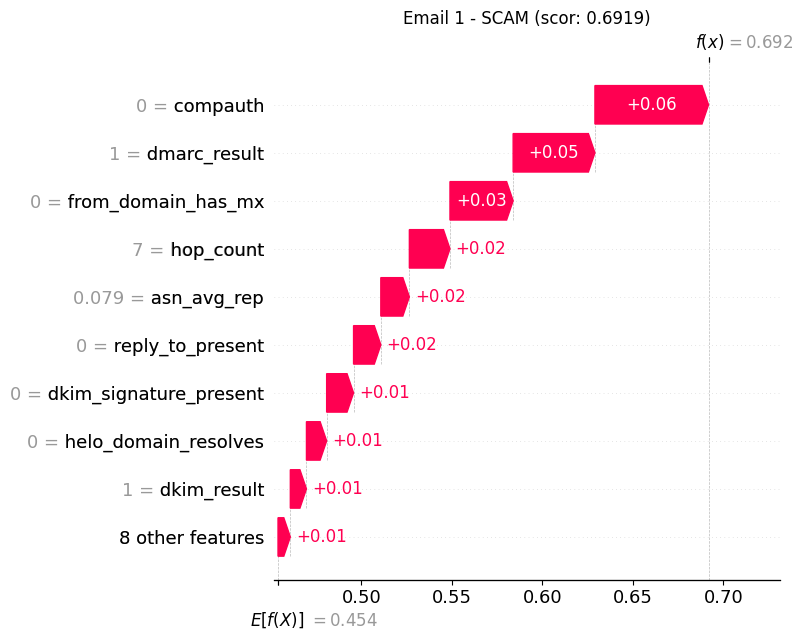

In [39]:
# train_raw = pd.read_csv('/kaggle/input/datasets/andreeabrleanu/tuiasi-dataset/train.csv')
# train_raw = pd.read_csv('/kaggle/input/datasets/andreeabrleanu/yahoo-dataset/train.csv')
train_raw = pd.read_csv('/kaggle/input/datasets/andreeabrleanu/hotmail-dataset/train.csv')

for col in manual_drop_cols:
    train_raw.drop(columns=[col], inplace=True)
cols_present = [c for c in cols_to_impute if c in train_raw.columns]
train_raw[cols_present] = imputer.transform(train_raw[cols_present])
X_train_bg = np.array(scaler.transform(train_raw), dtype=float)

bg_idx    = np.random.default_rng(42).choice(X_train_bg.shape[0], 50, replace=False)
explainer = shap.KernelExplainer(eif_final.anomaly_score, X_train_bg[bg_idx])

feature_names = list(df.columns)

for i in range(len(df)):
    sv = explainer.shap_values(X[i:i+1], nsamples=100, silent=True)

    label = 'SCAM' if predictions[i] == 1 else 'LEGITIM'
    score = scores[i]

    print(f"\n{'='*60}")
    print(f"Email {i+1} | Scor: {score:.4f} | Prag: {threshold} | Decizie: {label}")
    print(f"{'='*60}")

    shap_exp = shap.Explanation(
        values = sv[0],
        base_values = explainer.expected_value,
        data = df.iloc[i].values,
        feature_names = feature_names
    )

    plt.figure()
    shap.plots.waterfall(shap_exp, max_display=10, show=False)
    plt.title(f"Email {i+1} - {label} (scor: {score:.4f})")
    plt.tight_layout()
    plt.show()